In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from imutils.object_detection import non_max_suppression
import os
os.chdir(r"C:\Users\DT1\Desktop\proj-python\Images_Vision")


# HOG DETECTION FOR PEOPLE IMAGE

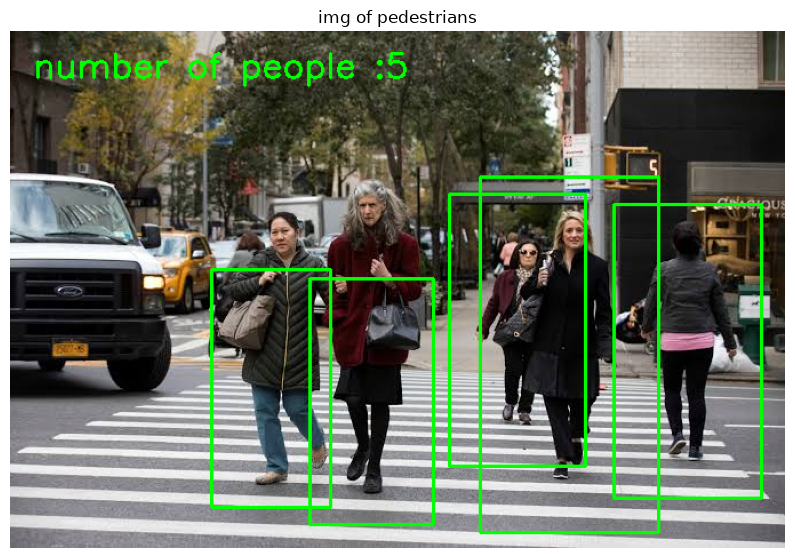

In [6]:
img=cv2.imread("pedestrian_3.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
hog_model=cv2.HOGDescriptor()
hog_model.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
bounding,weights=hog_model.detectMultiScale(img)
for x,y,w,h in bounding:
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
    num_people=len(bounding)
    cv2.putText(img,f"number of people :{num_people}",(20,40),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)
# cv2.imshow("img",img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("img of pedestrians")
plt.axis("off")
plt.show()

# HOG WITH VIDEO

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from imutils.object_detection import non_max_suppression
import imutils
from PIL import Image
import time
os.chdir(r"C:\Users\DT1\Desktop\proj-python\Videos")


In [14]:
cap=cv2.VideoCapture("motion_walking.mp4")
fourcc=cv2.VideoWriter_fourcc(*'XVID')
out=cv2.VideoWriter("output.avi",fourcc,20.0,(640,320))

cv2.namedWindow("frame",cv2.WINDOW_NORMAL)
cv2.resizeWindow("frame",640,320)

h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
video_fps=cap.get(cv2.CAP_PROP_FPS)

print("Height:",h)
print("Width:",w)
print("Video FPS:",video_fps)

hog_model=cv2.HOGDescriptor()
hog_model.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
prev_time=time.time()
while cap.isOpened():
  ret,frame=cap.read()
  if ret:
    frame=cv2.resize(frame,(640,320))
    curr_time=time.time()
    fps=1/(curr_time-prev_time)
    prev_time=curr_time
    bounding,weights=hog_model.detectMultiScale(frame,winStride=(4,4),padding=(8,8),scale=1.03)
    # for x,y,w,h in bounding:
    #   cv2.rectangle(frame,(x,y),(x+w,y+h),(0,0,255),2)
    boxes=np.array([[x,y,x+w,y+h] for (x,y,w,h) in bounding])
    select=non_max_suppression(boxes,probs=None,overlapThresh=0.45)
    for x,y,w,h in select:
      cv2.rectangle(frame,(x,y),(w,h),(0,255,0),2)
      num_people=len(bounding)
      cv2.putText(frame,"Person",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)
      cv2.putText(frame,f"Total People: {num_people}",(20,30),cv2.FONT_HERSHEY_DUPLEX,0.8,(0,0,255),2)
      cv2.putText(frame,f"FPS: {int(fps)}",(20,70),cv2.FONT_HERSHEY_DUPLEX,0.8,(0,0,255),2)
    cv2.imshow("frame",frame)
    out.write(frame)

    key=cv2.waitKey(2)& 0xFF
    if key==ord('q'):
      break
  else:
    break
cap.release()
out.release()
cv2.destroyAllWindows()

Height: 360
Width: 640
Video FPS: 29.97002997002997
